# Generative AI models comparison: Two Frequencies Cosine dataset

### Setup

In [1]:
from google.colab import drive
import os
import sys
import torch

drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 4/results/notebook'
%cd "{PROJECT_PATH}"

BASE_DIR = os.path.abspath("..")
DATA_DIR = os.path.join(BASE_DIR, "data")
IMAGE_DIR = os.path.join(BASE_DIR, "saved_images")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n[INFO] Running on device: {device}\n")

Mounted at /content/drive
/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 4/results/notebook

[INFO] Running on device: cpu



In [2]:
from functools import partial

from utils import (
    load_data,
    extract_generated_functions,
    save_image,
)

from utils_plots import (
    plot_function_grid,
    plot_forward_processes,
    plot_generation_processes,
)

from metrics import (
    fit_phases_dataset,
    phase_parametric_model,
    residual_MSE,
    plot_mse_comparison,
    fit_amplitudes,
    amplitudes_parametric_model,
    plot_phase_amplitude_grid,
)

### Load saved results

In [3]:
# data_train
keys = ["data", "seed", "x_inf", "x_sup", "a_low", "a_high", "w_low", "w_high", "theta_min", "theta_max", "theta_true"]
data_train, seed, x_inf, x_sup, a_low, a_high, w_low, w_high, theta_min, theta_max, theta_true = load_data(DATA_DIR, "dataset_samples.pt", keys)
axis_x = torch.linspace(x_inf, x_sup, data_train.shape[-1])
print(data_train.shape)

torch.Size([2000, 1, 128])


In [4]:
# flow matching

# interpolation process
keys = ["data", "t_0", "t_end", "t_eps"]
flow_interpolation, t_0, t_end, t_eps_flow= load_data(DATA_DIR, "forward_flow_interpolation.pt", keys)
print(flow_interpolation.shape)

# generation process
keys = ["data", "seed"]
flow_generation, seed = load_data(DATA_DIR, "generated_flow_samples.pt", keys)
print(flow_generation.shape)

torch.Size([2000, 100, 1, 128])
torch.Size([2000, 100, 1, 128])


In [5]:
# isotropic diffusion

# forward process
keys = ["data", "t_0", "t_end", "t_eps"]
forward_diffusion, _, _, t_eps_diffusion= load_data(DATA_DIR, "forward_diffusion_process.pt", keys)
print(forward_diffusion.shape)

# generation process
keys = ["data", "seed"]
diffusion_generation, seed = load_data(DATA_DIR, "generated_diffusion_samples.pt", keys)
print(diffusion_generation.shape)

torch.Size([2000, 100, 1, 128])
torch.Size([2000, 101, 1, 128])


In [6]:
# low frequency diffusion

# forward process
keys = ["data", "t_0", "t_end", "t_eps"]
forward_low_freq_diffusion, _, _, t_eps_low_freq_diffusion= load_data(DATA_DIR, "forward_low_freq_diffusion_process.pt", keys)
print(forward_low_freq_diffusion.shape)

# generation process
keys = ["data", "seed"]
low_freq_diffusion_generation, seed = load_data(DATA_DIR, "generated_low_freq_diffusion_samples.pt", keys)
print(low_freq_diffusion_generation.shape)

torch.Size([2000, 100, 1, 128])
torch.Size([2000, 101, 1, 128])


In [7]:
# high frequency diffusion

# forward process
keys = ["data", "t_0", "t_end", "t_eps"]
forward_high_freq_diffusion, _, _, t_eps_high_freq_diffusion= load_data(DATA_DIR, "forward_high_freq_diffusion_process.pt", keys)
print(forward_high_freq_diffusion.shape)

# generation process
keys = ["data", "seed"]
high_freq_diffusion_generation, seed = load_data(DATA_DIR, "generated_high_freq_diffusion_samples.pt", keys)
print(high_freq_diffusion_generation.shape)

torch.Size([2000, 100, 1, 128])
torch.Size([2000, 101, 1, 128])


### Extract generated functions

In [8]:
# flow matching
flow_samples = extract_generated_functions(generated_samples=flow_generation)
print(flow_samples.shape)

# isotropic diffusion process
diffusion_samples = extract_generated_functions(generated_samples=diffusion_generation)
print(diffusion_samples.shape)

# low frequency diffusion process
low_freq_diffusion_samples = extract_generated_functions(generated_samples=low_freq_diffusion_generation)
print(low_freq_diffusion_samples.shape)

# high frequency diffusion process
high_freq_diffusion_samples = extract_generated_functions(generated_samples=high_freq_diffusion_generation)
print(high_freq_diffusion_samples.shape)

torch.Size([2000, 1, 128])
torch.Size([2000, 1, 128])
torch.Size([2000, 1, 128])
torch.Size([2000, 1, 128])


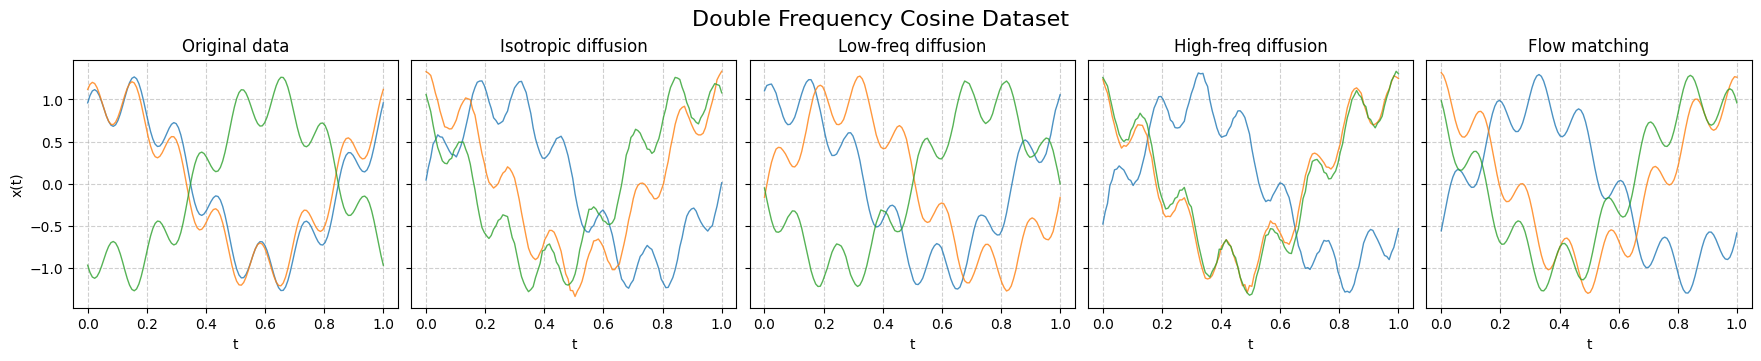

In [9]:
fig_samples = plot_function_grid(
    {"Original data": data_train, "Isotropic diffusion": diffusion_samples, "Low-freq diffusion": low_freq_diffusion_samples, "High-freq diffusion": high_freq_diffusion_samples, "Flow matching": flow_samples, },
    axis_x=axis_x, seed=seed, mode="overlapped", n_samples=3, suptitle="Double Frequency Cosine Dataset",)

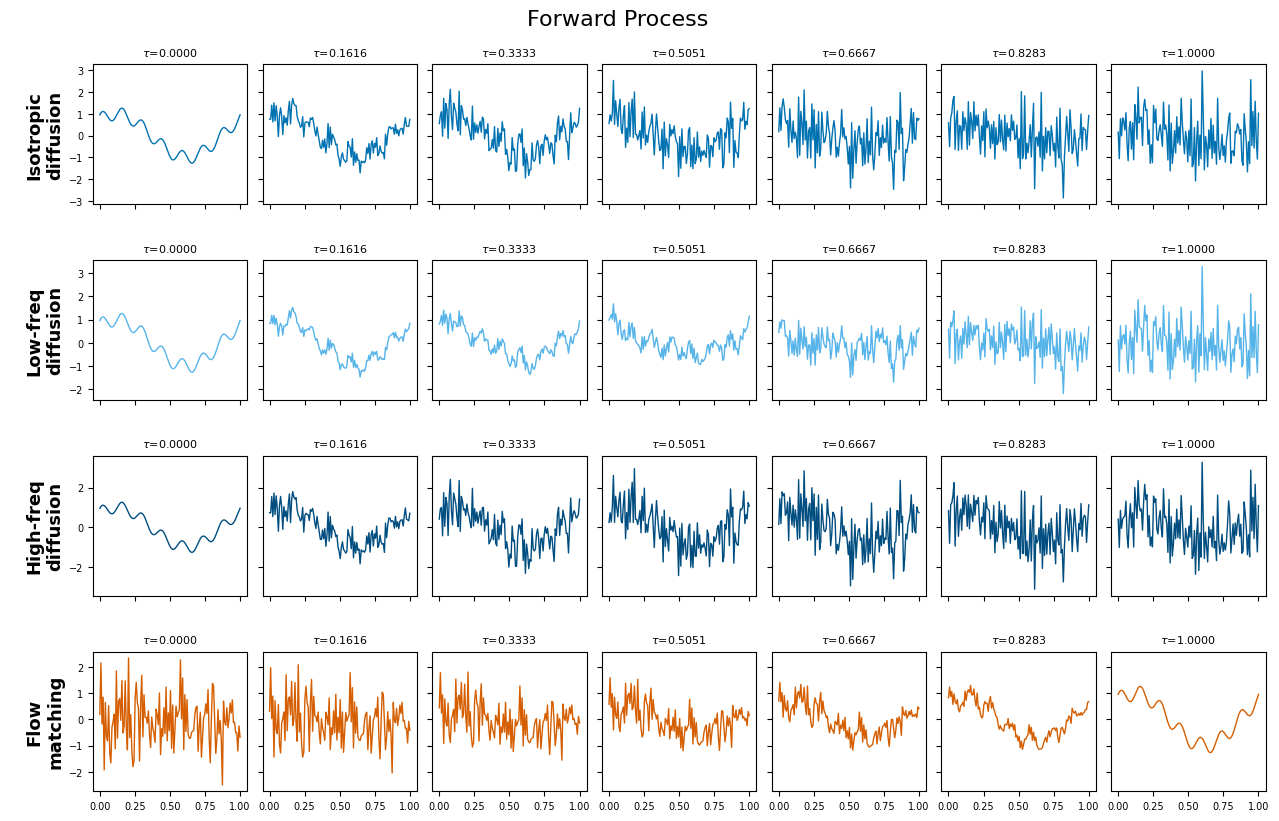

In [10]:
models = {
    "Isotropic\ndiffusion": {"process": forward_diffusion, "t_start": t_0, "t_end": t_end, "scale": "linear"},
    "Low-freq\ndiffusion": {"process": forward_low_freq_diffusion, "t_start": t_0, "t_end": t_end, "scale": "linear"},
    "High-freq\ndiffusion": {"process": forward_high_freq_diffusion, "t_start": t_0, "t_end": t_end, "scale": "linear"},
    "Flow\nmatching": {"process": flow_interpolation, "t_start": t_0, "t_end": t_end, "scale": "linear"},
    }

MODEL_COLORS = {
    "Original\ndata": "#4D4D4D",
    "Estimated\ndata": "#6A8F00",
    "Isotropic\ndiffusion": "#0072B2",
    "Low-freq\ndiffusion": "#56B4E9",
    "High-freq\ndiffusion": "#004D80",
    "Flow\nmatching": "#D55E00",
}

fig_forward = plot_forward_processes(models, axis_x, num_steps=7, n_samples=1, cell_size=(3.0, 3.0), colors=MODEL_COLORS)

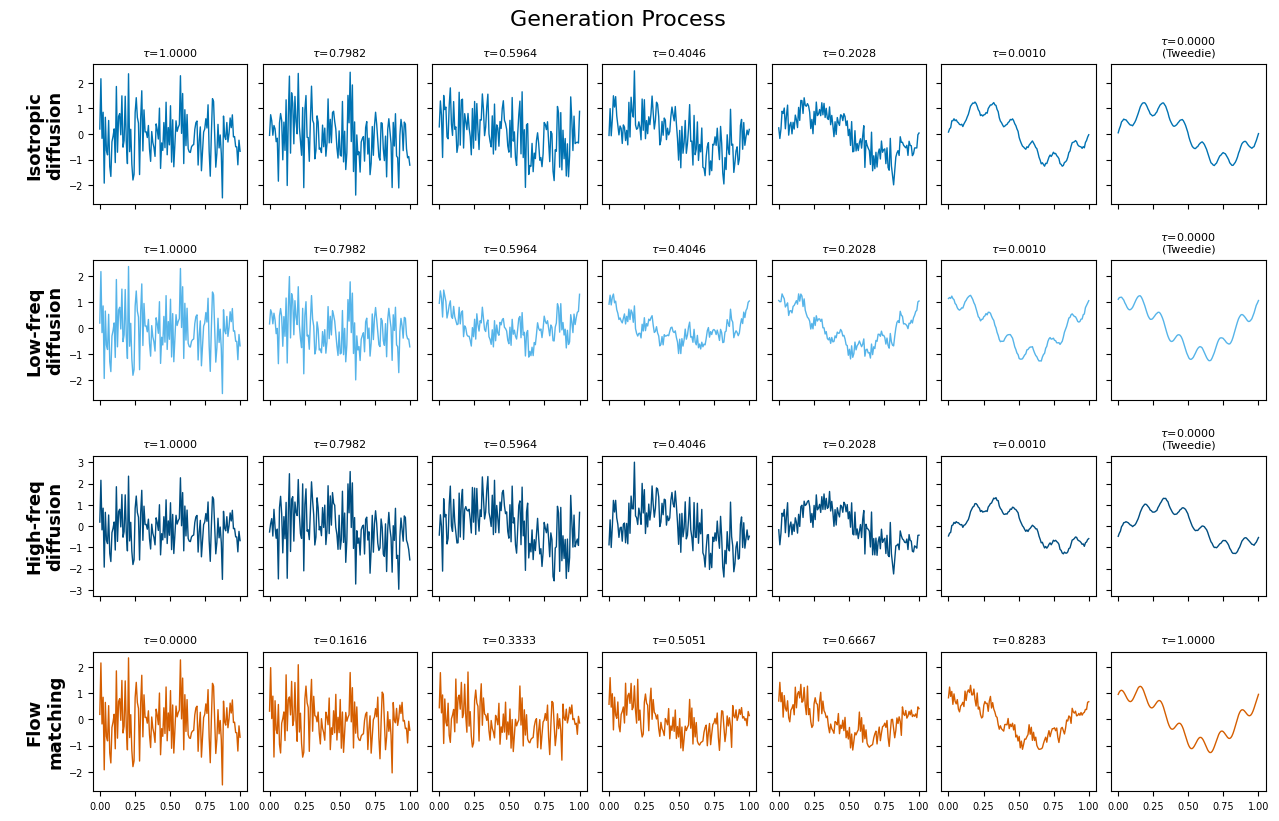

In [11]:
models = {
    "Isotropic\ndiffusion": {"process": diffusion_generation, "t_start": t_end, "t_end": t_eps_diffusion, "scale": "linear", "tweedie_final": True},
    "Low-freq\ndiffusion": {"process": low_freq_diffusion_generation, "t_start": t_end, "t_end": t_eps_low_freq_diffusion, "scale": "linear", "tweedie_final": True},
    "High-freq\ndiffusion": {"process": high_freq_diffusion_generation, "t_start": t_end, "t_end": t_eps_high_freq_diffusion, "scale": "linear", "tweedie_final": True},
    "Flow\nmatching": {"process": flow_interpolation, "t_start": t_0, "t_end": t_end, "scale": "linear"},
    }

MODEL_COLORS = {
    "Original\ndata": "#4D4D4D",
    "Estimated\ndata": "#6A8F00",
    "Isotropic\ndiffusion": "#0072B2",
    "Low-freq\ndiffusion": "#56B4E9",
    "High-freq\ndiffusion": "#004D80",
    "Flow\nmatching": "#D55E00",
}

fig_generation = plot_generation_processes(models, axis_x, num_steps=7, n_samples=1, cell_size=(3.0, 3.0), colors=MODEL_COLORS)

### Metrics comparison

In [12]:
theta_diffusion, _ = fit_phases_dataset(
    diffusion_samples,
    axis_x,
    parametric_model=partial(phase_parametric_model, a_1=a_low, a_2=a_high, w_1=w_low, w_2=w_high),
    device=device,
)

mses_diffusion = residual_MSE(
    diffusion_samples,
    theta_diffusion,
    axis_x,
    parametric_model=partial(phase_parametric_model, a_1=a_low, a_2=a_high, w_1=w_low, w_2=w_high),
    device=device,
)

theta_low_freq_diffusion, _ = fit_phases_dataset(
    low_freq_diffusion_samples,
    axis_x,
    parametric_model=partial(phase_parametric_model, a_1=a_low, a_2=a_high, w_1=w_low, w_2=w_high),
    device=device,
)

mses_low_freq_diffusion = residual_MSE(
    low_freq_diffusion_samples,
    theta_low_freq_diffusion,
    axis_x,
    parametric_model=partial(phase_parametric_model, a_1=a_low, a_2=a_high, w_1=w_low, w_2=w_high),
    device=device,
)

theta_high_freq_diffusion, _ = fit_phases_dataset(
    high_freq_diffusion_samples,
    axis_x,
    parametric_model=partial(phase_parametric_model, a_1=a_low, a_2=a_high, w_1=w_low, w_2=w_high),
    device=device,
)

mses_high_freq_diffusion = residual_MSE(
    high_freq_diffusion_samples,
    theta_high_freq_diffusion,
    axis_x,
    parametric_model=partial(phase_parametric_model, a_1=a_low, a_2=a_high, w_1=w_low, w_2=w_high),
    device=device,
)

theta_flow, _ = fit_phases_dataset(
    flow_samples,
    axis_x,
    parametric_model=partial(phase_parametric_model, a_1=a_low, a_2=a_high, w_1=w_low, w_2=w_high),
    device=device,
)

mses_flow = residual_MSE(
    flow_samples,
    theta_flow,
    axis_x,
    parametric_model=partial(phase_parametric_model, a_1=a_low, a_2=a_high, w_1=w_low, w_2=w_high),
    device=device,
)

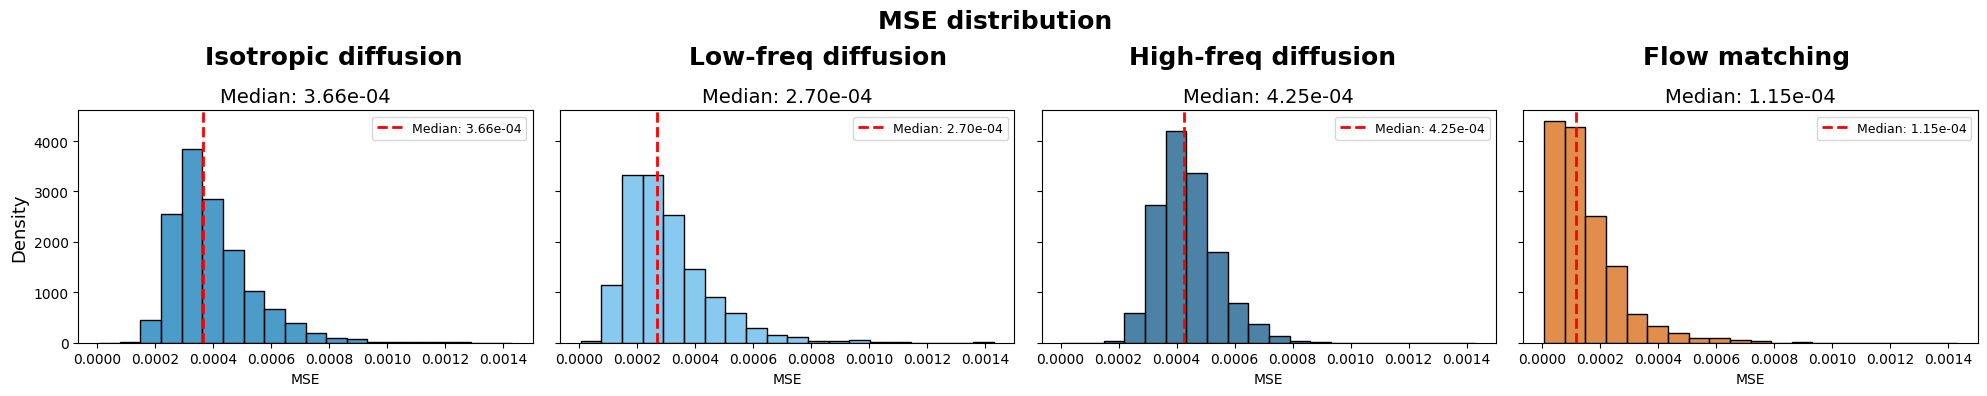

In [13]:
models = {
    "Isotropic diffusion": {"mse": mses_diffusion},
    "Low-freq diffusion": {"mse": mses_low_freq_diffusion},
    "High-freq diffusion": {"mse": mses_high_freq_diffusion},
    "Flow matching": {"mse": mses_flow},
}

MODEL_COLORS = {
    "Original data": "#4D4D4D",
    "Estimated data": "#6A8F00",
    "Isotropic diffusion": "#0072B2",
    "Low-freq diffusion": "#56B4E9",
    "High-freq diffusion": "#004D80",
    "Flow matching": "#D55E00",
}


fig_mse = plot_mse_comparison(models, cell_size=(5.0, 4.0), colors=MODEL_COLORS)

In [14]:
theta_estimated, _ = fit_phases_dataset(
    data_train,
    axis_x,
    parametric_model=partial(phase_parametric_model, a_1=a_low, a_2=a_high, w_1=w_low, w_2=w_high),
    device=device,
)

hat_a1_estimated, hat_a2_estimated = fit_amplitudes(
    samples=data_train,
    x_grid=axis_x,
    parametric_model=partial(amplitudes_parametric_model, w_1=w_low, w_2=w_high, phase_hat=theta_estimated),
    device=device,
)

hat_a1_diffusion, hat_a2_diffusion = fit_amplitudes(
    samples=diffusion_samples,
    x_grid=axis_x,
    parametric_model=partial(amplitudes_parametric_model, w_1=w_low, w_2=w_high, phase_hat=theta_diffusion),
    device=device,
)

hat_a1_low_freq_diffusion, hat_a2_low_freq_diffusion = fit_amplitudes(
    samples=low_freq_diffusion_samples,
    x_grid=axis_x,
    parametric_model=partial(amplitudes_parametric_model, w_1=w_low, w_2=w_high, phase_hat=theta_low_freq_diffusion),
    device=device,
)

hat_a1_high_freq_diffusion, hat_a2_high_freq_diffusion = fit_amplitudes(
    samples=high_freq_diffusion_samples,
    x_grid=axis_x,
    parametric_model=partial(amplitudes_parametric_model, w_1=w_low, w_2=w_high, phase_hat=theta_high_freq_diffusion),
    device=device,
)

hat_a1_flow, hat_a2_flow = fit_amplitudes(
    samples=flow_samples,
    x_grid=axis_x,
    parametric_model=partial(amplitudes_parametric_model, w_1=w_low, w_2=w_high, phase_hat=theta_flow),
    device=device,
)

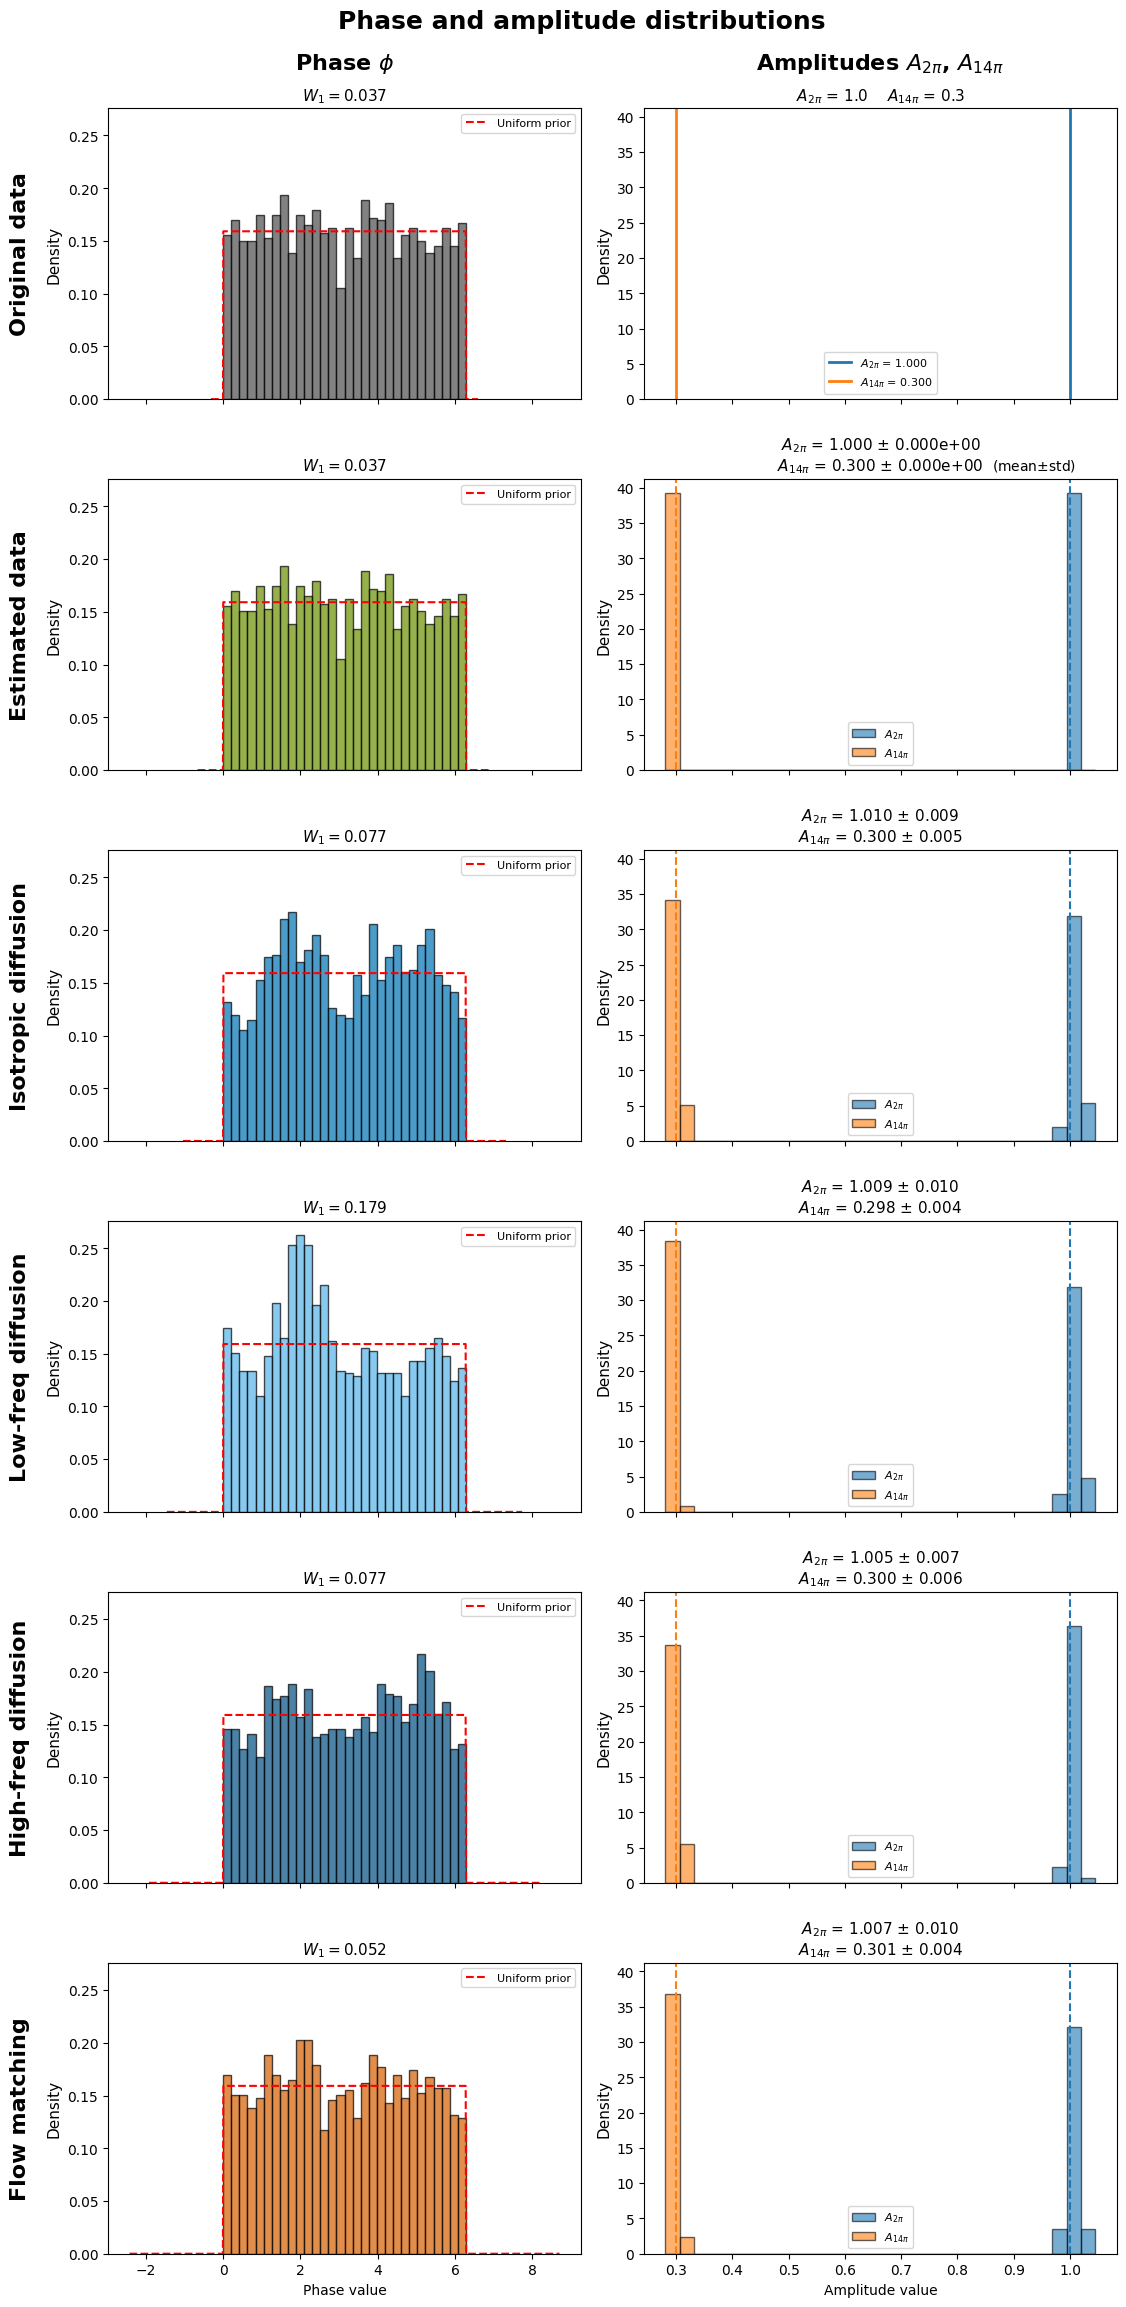

In [15]:
models = {
    "Original data": {"theta": theta_true, "a1": a_low, "a2": a_high},
    "Estimated data": {"theta": theta_estimated, "a1": hat_a1_estimated, "a2": hat_a2_estimated},
    "Isotropic diffusion": {"theta": theta_diffusion, "a1": hat_a1_diffusion, "a2": hat_a2_diffusion},
    "Low-freq diffusion": {"theta": theta_low_freq_diffusion, "a1": hat_a1_low_freq_diffusion, "a2": hat_a2_low_freq_diffusion},
    "High-freq diffusion": {"theta": theta_high_freq_diffusion, "a1": hat_a1_high_freq_diffusion, "a2": hat_a2_high_freq_diffusion},
    "Flow matching": {"theta": theta_flow, "a1": hat_a1_flow, "a2": hat_a2_flow},
}

MODEL_COLORS = {
    "Original data": "#4D4D4D",
    "Estimated data": "#6A8F00",
    "Isotropic diffusion": "#0072B2",
    "Low-freq diffusion": "#56B4E9",
    "High-freq diffusion": "#004D80",
    "Flow matching": "#D55E00",
}

fig_parameters = plot_phase_amplitude_grid(
    models, phase_min=theta_min[0], phase_max=theta_max[0], theoretical_a1=a_low, theoretical_a2=a_high, colors=MODEL_COLORS)

In [16]:
save_image(fig_samples, IMAGE_DIR, "fig_twofreqcosine_samples.pdf")
save_image(fig_forward, IMAGE_DIR, "fig_twofreqcosine_forward.pdf")
save_image(fig_generation, IMAGE_DIR, "fig_twofreqcosine_generation.pdf")
save_image(fig_mse, IMAGE_DIR, "fig_twofreqcosine_mse.pdf")
save_image(fig_parameters, IMAGE_DIR, "fig_twofreqcosine_parameters.pdf")


Saved -> /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 4/results/saved_images/fig_twofreqcosine_samples.pdf
Saved -> /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 4/results/saved_images/fig_twofreqcosine_forward.pdf
Saved -> /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 4/results/saved_images/fig_twofreqcosine_generation.pdf
Saved -> /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 4/results/saved_images/fig_twofreqcosine_mse.pdf
Saved -> /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 4/results/saved_images/fig_twofreqcosine_parameters.pdf


PosixPath('/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 4/results/saved_images/fig_twofreqcosine_parameters.pdf')